In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


In [2]:
# Load processed dataset
merged_data = pd.read_pickle(r"C:\Users\shuddhabrota\OneDrive\Desktop\Devcraft\processed_data.pkl")


In [3]:
merged_data.describe()

,Region,City,Adexchange,Adslotwidth,Adslotheight,Adslotvisibility,Adslotformat,Adslotfloorprice,Biddingprice,AdvertiserID,...,OS_iOS,DeviceType_Desktop,DeviceType_Mobile,DeviceType_Tablet,AdslotID,Hour,Weekday,Clicked,Converted,Browser
count,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,...,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1651523.0,1.651523e+06,1.651523e+06,1.651523e+06
mean,-5.111190e-18,6.129986e-17,-3.827369e-16,-1.470371e-16,4.956305e-18,1.301030e-17,9.912611e-18,-1.239076e-17,-2.714954e-16,5.754821e-17,...,1.651506e-02,9.722450e-01,2.272569e-02,5.029297e-03,3.387441e+04,1.330337e+01,6.0,6.914830e-04,1.695405e-05,4.868267e+05
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.274454e-01,1.642701e-01,1.490277e-01,7.073900e-02,5.532488e+04,6.520600e+00,0.0,2.628698e-02,4.117496e-03,1.701375e+05
min,-1.402016e+00,-1.432165e+00,-1.283004e+00,-1.471654e+00,-9.748303e-01,-1.276681e-01,-5.649426e-01,-7.274496e-01,-1.384292e+00,-1.700847e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,6.0,0.000000e+00,0.000000e+00,1.000000e+00
25%,-7.687484e-01,-7.016028e-01,-1.283004e+00,-9.140023e-01,-7.435429e-01,-1.276681e-01,-5.649426e-01,-7.274496e-01,-1.026734e+00,-1.700847e+00,...,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,6.440000e+02,1.000000e+01,6.0,0.000000e+00,0.000000e+00,2.773160e+05
50%,-1.066964e-01,-4.694318e-02,-4.287637e-02,-3.935275e-01,-7.435429e-01,-1.276681e-01,-5.649426e-01,-5.930658e-01,-5.066483e-01,5.503910e-01,...,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,4.488000e+03,1.400000e+01,6.0,0.000000e+00,0.000000e+00,5.091840e+05
75%,6.800900e-01,6.836190e-01,1.197252e+00,1.254643e+00,4.899896e-01,-4.051748e-02,1.127732e+00,8.582791e-01,9.885972e-01,5.982649e-01,...,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,2.304100e+04,1.800000e+01,6.0,0.000000e+00,0.000000e+00,6.518580e+05
max,2.397587e+00,2.362963e+00,1.197252e+00,1.254643e+00,3.188342e+00,1.098404e+01,7.898430e+00,7.201194e+00,9.885972e-01,6.554800e-01,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.542710e+05,2.300000e+01,6.0,1.000000e+00,1.000000e+00,6.518580e+05


In [4]:
merged_data = merged_data.drop(['Weekday', 'Payingprice'], axis = 1)

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols = ["Adslotwidth", "Adslotheight"]
# Scale a single column (e.g., "Biddingprice")
merged_data[cols] = scaler.fit_transform(merged_data[cols])

In [6]:
merged_data.describe()

,Region,City,Adexchange,Adslotwidth,Adslotheight,Adslotvisibility,Adslotformat,Adslotfloorprice,Biddingprice,AdvertiserID,...,OS_Windows,OS_iOS,DeviceType_Desktop,DeviceType_Mobile,DeviceType_Tablet,AdslotID,Hour,Clicked,Converted,Browser
count,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,...,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06,1.651523e+06
mean,-5.111190e-18,6.129986e-17,-3.827369e-16,5.397996e-01,2.341556e-01,1.301030e-17,9.912611e-18,-1.239076e-17,-2.714954e-16,5.754821e-17,...,9.729934e-01,1.651506e-02,9.722450e-01,2.272569e-02,5.029297e-03,3.387441e+04,1.330337e+01,6.914830e-04,1.695405e-05,4.868267e+05
std,1.000000e+00,1.000000e+00,1.000000e+00,3.667981e-01,2.402015e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.621026e-01,1.274454e-01,1.642701e-01,1.490277e-01,7.073900e-02,5.532488e+04,6.520600e+00,2.628698e-02,4.117496e-03,1.701375e+05
min,-1.402016e+00,-1.432165e+00,-1.283004e+00,0.000000e+00,0.000000e+00,-1.276681e-01,-5.649426e-01,-7.274496e-01,-1.384292e+00,-1.700847e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,-7.687484e-01,-7.016028e-01,-1.283004e+00,2.045455e-01,5.555556e-02,-1.276681e-01,-5.649426e-01,-7.274496e-01,-1.026734e+00,-1.700847e+00,...,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,6.440000e+02,1.000000e+01,0.000000e+00,0.000000e+00,2.773160e+05
50%,-1.066964e-01,-4.694318e-02,-4.287637e-02,3.954545e-01,5.555556e-02,-1.276681e-01,-5.649426e-01,-5.930658e-01,-5.066483e-01,5.503910e-01,...,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,4.488000e+03,1.400000e+01,0.000000e+00,0.000000e+00,5.091840e+05
75%,6.800900e-01,6.836190e-01,1.197252e+00,1.000000e+00,3.518519e-01,-4.051748e-02,1.127732e+00,8.582791e-01,9.885972e-01,5.982649e-01,...,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,2.304100e+04,1.800000e+01,0.000000e+00,0.000000e+00,6.518580e+05
max,2.397587e+00,2.362963e+00,1.197252e+00,1.000000e+00,1.000000e+00,1.098404e+01,7.898430e+00,7.201194e+00,9.885972e-01,6.554800e-01,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.542710e+05,2.300000e+01,1.000000e+00,1.000000e+00,6.518580e+05


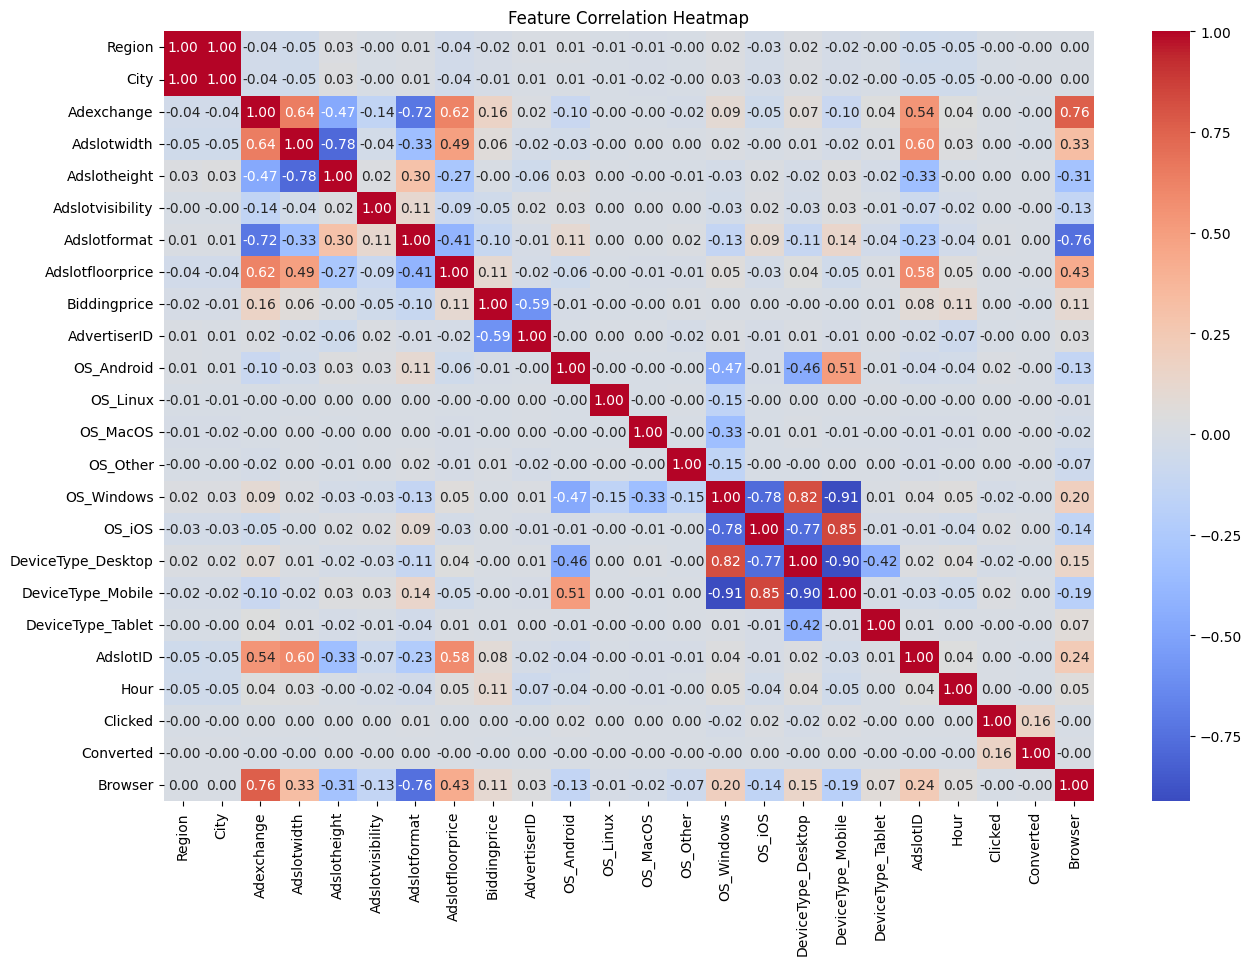

In [7]:
# Correlation Heatmap
plt.figure(figsize=(15, 10))
corr = merged_data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

In [8]:
# Create the 'Area' column
merged_data["Area"] = merged_data["Adslotheight"] * merged_data["Adslotwidth"]

# Drop the original 'height' and 'width' columns
merged_data.drop(columns=["Adslotheight", "Adslotwidth"], inplace=True)

In [9]:
merged_data.head()

,Region,City,Adexchange,Adslotvisibility,Adslotformat,Adslotfloorprice,Biddingprice,AdvertiserID,OS_Android,OS_Linux,...,OS_iOS,DeviceType_Desktop,DeviceType_Mobile,DeviceType_Tablet,AdslotID,Hour,Clicked,Converted,Browser,Area
0,-1.363636,-1.327799,-1.283004,-0.040517,1.127732,-0.727450,-1.384292,0.598265,0.0,0.0,...,0.0,1.0,0.0,0.0,3574.0,0.0,0.0,0.0,277316.0,0.071970
1,0.008443,-0.008992,-1.283004,-0.040517,1.127732,-0.727450,0.988597,0.550391,0.0,0.0,...,0.0,1.0,0.0,0.0,2877.0,0.0,0.0,0.0,207148.0,0.071970
2,-0.106696,-0.141821,-1.283004,-0.040517,1.127732,-0.727450,-1.384292,0.598265,0.0,0.0,...,0.0,1.0,0.0,0.0,2316.0,0.0,0.0,0.0,277316.0,0.052399
3,0.680090,0.683619,-0.042876,-0.040517,-0.564943,-0.593066,0.988597,0.550391,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,509184.0,0.038384
4,0.680090,0.787985,-0.042876,-0.084093,-0.564943,-0.593066,0.988597,-1.700847,0.0,0.0,...,0.0,1.0,0.0,0.0,50.0,0.0,0.0,0.0,509184.0,0.051978


In [10]:
merged_data.columns

Index(['Region', 'City', 'Adexchange', 'Adslotvisibility', 'Adslotformat',
       'Adslotfloorprice', 'Biddingprice', 'AdvertiserID', 'OS_Android',
       'OS_Linux', 'OS_MacOS', 'OS_Other', 'OS_Windows', 'OS_iOS',
       'DeviceType_Desktop', 'DeviceType_Mobile', 'DeviceType_Tablet',
       'AdslotID', 'Hour', 'Clicked', 'Converted', 'Browser', 'Area'],
      dtype='object')

In [11]:
merged_data.shape

(1651523, 23)

In [12]:
merged_data.to_pickle("eda_data.pkl")